In [112]:
# import zone
import pandas as pd
# matplotlib : 메트플롯 반드시 import 한다
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline
# seaborn : matplotlib 기간의 차트 예쁘게 꾸미는 도구
import seaborn as sns

sns.set_style('whitegrid')  # 배경 스타일 - dark : 그리도 없이 어두운 배경
# sns.set_palette('deep')  # 막대 색상 스타일 - deep : 진하게

pd.set_option('display.max_columns', None)  # 모든 컬럼 출력
pd.set_option('display.width', 1000)  # 출력 너비 지정
pd.set_option('display.unicode.east_asian_width', True)  # 모든 컬럼 출력

booking = pd.read_csv('charangData/booking.csv', encoding= 'cp949')
car = pd.read_csv('charangData/car.csv', encoding= 'cp949')
branch = pd.read_csv('charangData/branch.csv', encoding= 'cp949')
user = pd.read_csv('charangData/user.csv', encoding= 'cp949')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 6. **브랜드별 예약 횟수** (brand_reserve_count)
#### - **그래프유형**: 원형그래프
#### - **기대효과**: 추후 들여올 차량 브랜드 선정시 유효
#### - **항목값**: 수(Count)
#### - **Raw Data**: booking Table / car Table

brand
렉사드       81
BYZ         100
볼바즈      113
제네러스    119
토유        131
아우디즈    153
DMW         157
빈츠        157
한대        283
크아        285
dtype: int64


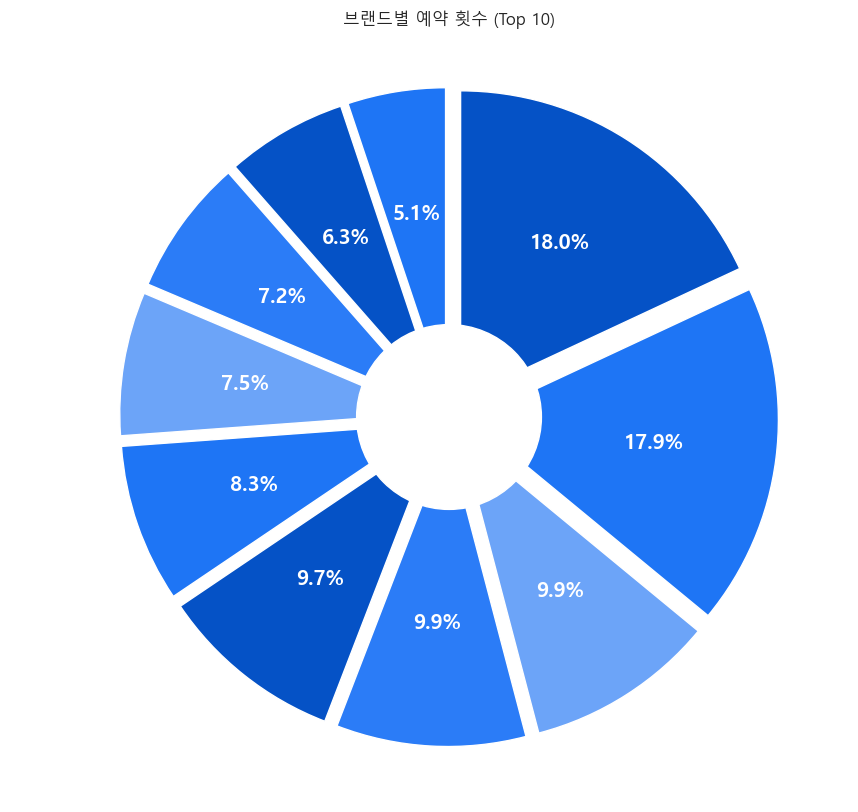

In [113]:
# merge - booking, car
merge06 = pd.merge(booking, car, how='outer', on='carId')
merge06

mer06Cnt = merge06.groupby('brand').size().sort_values(ascending=False).head(10).sort_values(ascending=True)

print(mer06Cnt)

plt.figure(figsize=(10,10))

# plt.pie(mer06Cnt, labels=mer06Cnt.index, autopct='%1.1f%%', startangle=90)
plt.pie(
    mer06Cnt, 
    labels=mer06Cnt.index,
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#1e75f5', '#0552c6', '#2b7cf7', '#6ca4f8'], 
    wedgeprops={'edgecolor': 'white'}, 
    explode=[0.07] * len(mer06Cnt),
    textprops={
        'fontsize':15,
        'fontweight': 'bold',
        'color': 'white'
   })

cir = plt.Circle((0,0), 0.3, fc='white')
plt.gca().add_artist(cir)

plt.title('브랜드별 예약 횟수 (Top 10)')

plt.savefig('그래프6', transparent=True)  # 투명화 저장

plt.show()

['BYZ', 'DMW', '볼바즈', '빈츠', '아우디즈', '토유', '한크제', '기타']
[100, 157, 113, 157, 153, 131, 687, 283]
기타 :  313


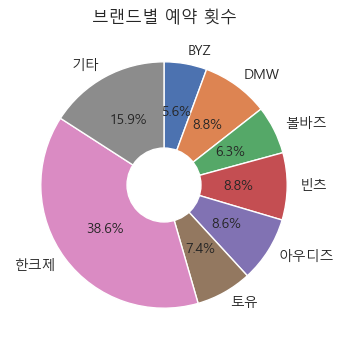

In [114]:
# merge - booking, car
merge06 = pd.merge(booking, car, how='outer', on='carId')
merge06

mer06Cnt = merge06.groupby('brand').size()
# print(mer06Cnt)

# 3% 미만은 기타 로 분류
new_key = []  # 라벨
new_value = []  # %
etc_total = 0  # 기타 총합

# 한대 크아 제네러스 통합
hkj = ['한대', '크아', '제네러스']
hkj_total = 0

for key, value in mer06Cnt.items() :
    if value < 100 :  # 50 이하 etc에 담기
        etc_total += value
    elif key == '한대' :  # 한대, 크아, 제네러스는 합산해서 한크제로 담음
        hkj_total += value
    elif key == '크아' :  # 한대, 크아, 제네러스는 합산해서 한크제로 담음
        hkj_total += value
    elif key == '제네러스' :  # 한대, 크아, 제네러스는 합산해서 한크제로 담음
        hkj_total += value
    else:  # 아니면 새로운 딕셔너리에 담음
        new_key.append(key)
        new_value.append(value)

if hkj_total >= 0 :
    new_key.append('한크제')
    new_value.append(hkj_total)
if etc_total >= 0 :
    new_key.append('기타')
    new_value.append(value)
        
print(new_key)
print(new_value)
print('기타 : ', etc_total)

plt.figure(figsize=(4,4))

plt.pie(new_value, labels=new_key, autopct='%1.1f%%', startangle=90, counterclock=False)

cir = plt.Circle((0,0), 0.3, fc='white')
plt.gca().add_artist(cir)

plt.title('브랜드별 예약 횟수')

plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12956\3172114490.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mer06Cnt[i],
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12956\3172114490.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  int(mer06Cnt[i]),


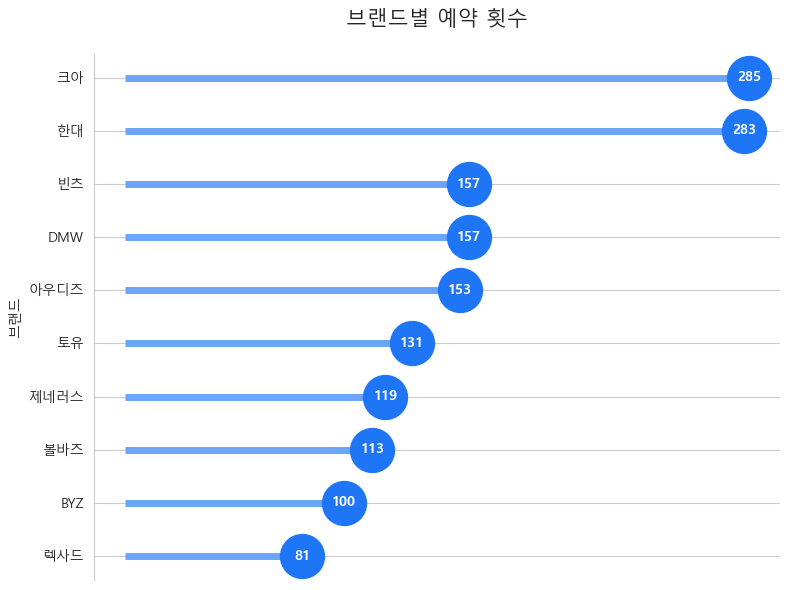

In [115]:
import matplotlib.pyplot as plt

# 데이터 집계 (기존 코드 유지)
mer06Cnt = merge06.groupby('brand').size().sort_values(ascending=False).head(10).sort_values(ascending=True)

# 그래프 설정
fig, ax = plt.subplots(figsize=(8, 6))

# 1. 막대 대신 선(Stick) 그리기
ax.hlines(y=mer06Cnt.index, xmin=0, xmax=mer06Cnt, color='#6ca4f8', linewidth=5)

# 2. 끝부분에 동그라미(Candy) 추가
# s는 원의 크기다. 숫자가 너무 작으면 글자가 삐져나오니 적당히 조절해.
ax.scatter(mer06Cnt, mer06Cnt.index, color='#1e75f5', s=1000, zorder=3)

# 3. 동그라미 안에 숫자 넣기
for i in range(len(mer06Cnt)):
    ax.text(
        mer06Cnt[i], 
        i, 
        int(mer06Cnt[i]), 
        ha='center', 
        va='center', 
        color='white', 
        fontsize=10, 
        fontweight='bold'
    )

# 4. 디자인 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([]) # x축 수치 숨기기 (원 안에 데이터가 있으니까)

plt.title('브랜드별 예약 횟수', fontsize=15, pad=20)
plt.ylabel('브랜드')

plt.tight_layout()
plt.show()

### 8. **지점별 예약수** (branch_reserve_count)
#### - **그래프유형**: 누적 막대그래프
#### - **기대효과**: 지점별 인기차량? 회원선호도 확인? 가능?
#### - **X축**: 년/월
#### - **Y축**: 지점별 누적 예약수
#### - **Raw Data**: branch Table / car Table / user Table / booking Table

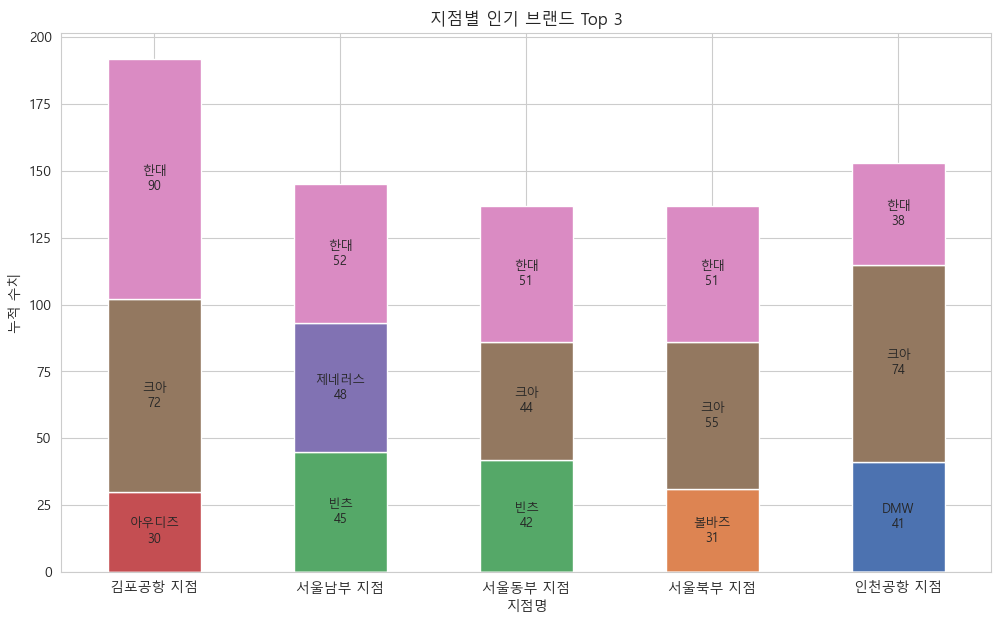

In [116]:
import matplotlib.pyplot as plt

# 1. merge - branch, car
merge08_BranchCar = pd.merge(branch, car, how='outer', on='branchId')
# 2. merge - user, booking
merge08_UserBook = pd.merge(user, booking, how='outer', on='userId')

# 3. merge - merge08_BranchCar, merge08_UserBook
merge08 = pd.merge(merge08_UserBook, merge08_BranchCar, how='inner', on='carId')

# 데이터 집계
counts = merge08.groupby(['name_y', 'brand']).size().reset_index(name='cnt')
top3 = counts.sort_values(['name_y', 'cnt'], ascending=[True, False]).groupby('name_y').head(3)

# 그래프 그리기용 피벗 테이블
table = top3.pivot(index='name_y', columns='brand', values='cnt').fillna(0)

# 그래프 출력
ax = table.plot(kind='bar', stacked=True, figsize=(12, 7), legend=False)

# 항목별 이름(brand)과 수치 표시
# 여기서 'c'는 브랜드별로 쌓인 막대 뭉치라고 생각하면 돼.
for c in ax.containers:
    brand = c.get_label()  # 브랜드 이름 가져오기
    # 각 칸의 중앙에 '브랜드명\n숫자'를 박아준다.
    labels = [f'{brand}\n{int(v)}' if v > 0 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9)

plt.title('지점별 인기 브랜드 Top 3')
plt.xlabel('지점명')
plt.ylabel('누적 수치')

plt.xticks(rotation=0)
# plt.legend(bbox_to_anchor=(1, 1)) # 범례는 밖으로 뺐다.
plt.show()